# Student Grade Predictor
## Multivariate Linear Regression

### Group Information
* **Group Members:** Gavin Steel, Emma, Jaelyn
* **Contributions:**
    * **Gavin Steel:** Organization & Presentation of Findings, Document Formatting.
    * **Emma:** Algorithm Design (Normal Equation & Gradient Descent), Feature Engineering.
    * **Jaelyn:** Algorithm Implementation and Data Preprocessing.

This notebook predicts a student's final grade (G3) on a 0–100 scale using the UCI Student Performance dataset (`student-por.csv`).

**Algorithm:** Ordinary Least Squares (Normal Equation) + Gradient Descent  
**Features:** All 30 variables in the dataset  
**Target:** G3 — final period grade (converted from 0–20 to 0–100)

## Section 1 — Imports

In [1]:
import csv
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

## Section 2 — Load Real Data

Reads `student-por.csv` (semicolon-separated) and returns the encoded feature matrix `X`, target grades `y`, and feature names.

> **Make sure `student-por.csv` is in the same folder as this notebook before running!**

In [2]:
JOBS      = ["teacher", "health", "services", "at_home"]  # 'other' = baseline
REASONS   = ["home", "reputation", "course"]               # 'other' = baseline
GUARDIANS = ["mother", "father"]                            # 'other' = baseline

def load_csv(filepath):
    rows = []
    with open(filepath, newline="", encoding="utf-8") as f:
        reader = csv.DictReader(f, delimiter=";")
        for row in reader:
            rows.append(row)

    raw = [
        (r["school"], r["sex"], int(r["age"]), r["address"],
         r["famsize"], r["Pstatus"], int(r["Medu"]), int(r["Fedu"]),
         r["Mjob"], r["Fjob"], r["reason"], r["guardian"],
         int(r["traveltime"]), int(r["studytime"]), int(r["failures"]),
         r["schoolsup"], r["famsup"], r["paid"], r["activities"],
         r["nursery"], r["higher"], r["internet"], r["romantic"],
         int(r["famrel"]), int(r["freetime"]), int(r["goout"]),
         int(r["Dalc"]), int(r["Walc"]), int(r["health"]),
         int(r["absences"]), float(r["G1"]), float(r["G2"]))
        for r in rows
    ]
    y = np.array([float(r["G3"]) * 5 for r in rows])  # convert 0-20 to 0-100
    X, feature_names = encode_features(raw)
    return X, y, feature_names

## Section 3 — Feature Encoding

Converts text categories into numbers so the math can work:
- **Binary** (e.g. school, sex) → 1 or 0
- **Numeric** (e.g. age, Medu) → kept as-is
- **Nominal** (e.g. Mjob, reason) → one-hot encoded (one column per category)

In [3]:
def encode_features(raw):
    rows = []
    for (school, sex, age, address, famsize, pstatus, Medu, Fedu,
         Mjob, Fjob, reason, guardian, traveltime, studytime, failures,
         schoolsup, famsup, paid, activities, nursery, higher, internet,
         romantic, famrel, freetime, goout, Dalc, Walc, health,
         absences, G1, G2) in raw:

        row = [
            1.0 if school  == "GP"  else 0.0,
            1.0 if sex     == "F"   else 0.0,
            float(age),
            1.0 if address == "U"   else 0.0,
            1.0 if famsize == "GT3" else 0.0,
            1.0 if pstatus == "T"   else 0.0,
            float(Medu),
            float(Fedu),
        ]
        for j in JOBS:
            row.append(1.0 if Mjob == j else 0.0)
        for j in JOBS:
            row.append(1.0 if Fjob == j else 0.0)
        for res in REASONS:
            row.append(1.0 if reason == res else 0.0)
        for g in GUARDIANS:
            row.append(1.0 if guardian == g else 0.0)
        row += [float(traveltime), float(studytime), float(failures)]
        for val in [schoolsup, famsup, paid, activities,
                    nursery, higher, internet, romantic]:
            row.append(1.0 if val == "yes" else 0.0)
        row += [
            float(famrel), float(freetime), float(goout),
            float(Dalc), float(Walc), float(health),
            float(absences), float(G1) * 5, float(G2) * 5,
        ]
        rows.append(row)

    feature_names = (
        ["school_GP", "sex_F", "age", "address_U", "famsize_GT3", "Pstatus_T", "Medu", "Fedu"]
        + [f"Mjob_{j}" for j in JOBS]
        + [f"Fjob_{j}" for j in JOBS]
        + [f"reason_{r}" for r in REASONS]
        + [f"guardian_{g}" for g in GUARDIANS]
        + ["traveltime", "studytime", "failures"]
        + ["schoolsup", "famsup", "paid", "activities",
           "nursery", "higher", "internet", "romantic"]
        + ["famrel", "freetime", "goout", "Dalc", "Walc", "health", "absences", "G1", "G2"]
    )
    return np.array(rows, dtype=float), feature_names

## Section 4 — Pre-processing

Three helpers:
1. **train_test_split** — splits data into 80% train / 20% test
2. **standardize** — Z-score normalization so no feature dominates
3. **add_bias** — adds a column of 1s for the intercept term

In [4]:
def train_test_split(X, y, test_ratio=0.2, seed=0):
    rng = np.random.default_rng(seed)
    idx = rng.permutation(len(y))
    cut = int(len(y) * (1 - test_ratio))
    tr, te = idx[:cut], idx[cut:]
    return X[tr], X[te], y[tr], y[te]

def standardize(X_train, X_test):
    mu    = X_train.mean(axis=0)
    sigma = X_train.std(axis=0)
    sigma[sigma == 0] = 1
    return (X_train - mu) / sigma, (X_test - mu) / sigma, mu, sigma

def add_bias(X):
    return np.hstack([np.ones((len(X), 1)), X])

## Section 5 — Models

The core of the project — two ways to solve Linear Regression:

**Normal Equation (OLS):** Solves directly with `w = (XᵀX)⁻¹Xᵀy`  
**Gradient Descent:** Iteratively adjusts weights to minimize MSE loss

In [5]:
def fit_normal_equation(X, y):
    """ w = (XᵀX)⁻¹ Xᵀy """
    return np.linalg.pinv(X.T @ X) @ X.T @ y

def fit_gradient_descent(X, y, lr=0.05, n_epochs=1000):
    """
    Batch gradient descent:
      w <- w - lr * (1/n) * X^T(Xw - y)
    """
    n, p = X.shape
    w, losses = np.zeros(p), []
    for _ in range(n_epochs):
        resid  = X @ w - y
        w     -= lr * (X.T @ resid) / n
        losses.append(float(np.mean(resid ** 2)))
    return w, losses

def predict(X, w):
    return X @ w

In [6]:
def ridge_regression(X, y, lam):
    n = X.shape[1]
    I = np.eye(n)
    return np.linalg.inv(X.T @ X + lam * I) @ X.T @ y

We applied **multiple linear regression techniques** to model the relationship between student features and final grade (G3). The dataset was first preprocessed by encoding categorical variables and standardizing numerical features. 

We then split the data into training and testing sets to evaluate model performance. Three regression approaches were used:

- Ordinary Least Squares (Normal Equation)
- Gradient Descent
- Ridge Regression (L2 Regularization)

## Section 6 — Metrics

Two numbers to evaluate how good our predictions are:
- **MSE** — average squared error (lower = better)
- **R²** — how much of the grade variation the model explains (closer to 1 = better)

In [7]:
def mse(y_true, y_pred):
    return float(np.mean((y_true - y_pred) ** 2))

def r2(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - y_true.mean()) ** 2)
    return float(1 - ss_res / ss_tot)

## Section 7 — Plots

Three visualizations:
1. **Predicted vs Actual** — how close our predictions are
2. **Loss Curve** — gradient descent converging over 1000 epochs
3. **Feature Importance** — which variables matter most
4. **Correlation Heatmap** - how each feature is correlated with the final grade

In [8]:
def plot_predictions(y_true, y_pred_ols, y_pred_gd):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle("Predicted vs Actual Final Grade (G3, scale 0-100)", fontsize=13, fontweight="bold")
    for ax, y_pred, label, color in zip(
        axes,
        [y_pred_ols, y_pred_gd],
        ["Normal Equation (OLS)", "Gradient Descent"],
        ["steelblue", "tomato"],
    ):
        ax.scatter(y_true, y_pred, alpha=0.6, color=color, edgecolors="white", s=60)
        lo, hi = min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())
        ax.plot([lo, hi], [lo, hi], "k--", lw=1.2, label="Perfect fit")
        ax.set_xlabel("Actual G3"); ax.set_ylabel("Predicted G3")
        ax.set_title(f"{label}  |  R² = {r2(y_true, y_pred):.4f}")
        ax.legend()
    plt.tight_layout()
    plt.show()

def plot_residuals(y_true, y_pred, title="Residual Plot"):
    residuals = y_true - y_pred
    plt.figure(figsize=(8, 5))
    plt.scatter(y_pred, residuals, alpha=0.5, color='purple', edgecolors='white')
    plt.axhline(0, color='black', linestyle='--', lw=2)
    plt.xlabel("Predicted G3")
    plt.ylabel("Residuals (Error)")
    plt.title(title)
    plt.tight_layout()
    plt.show()

def plot_loss_curve(losses):
    plt.figure(figsize=(7, 4))
    plt.plot(losses, color="tomato", lw=1.5)
    plt.xlabel("Epoch"); plt.ylabel("MSE Loss")
    plt.title("Gradient Descent - Training Loss Curve")
    plt.tight_layout()
    plt.show()

def plot_coefficients(w_ols, feature_names):
    coefs = w_ols[1:]
    idx   = np.argsort(np.abs(coefs))[::-1]
    names, vals = [feature_names[i] for i in idx], coefs[idx]
    colors = ["steelblue" if v >= 0 else "tomato" for v in vals]
    plt.figure(figsize=(10, 8))
    plt.barh(names[::-1], vals[::-1], color=colors[::-1])
    plt.axvline(0, color="black", lw=0.8)
    plt.xlabel("Coefficient (standardised features)")
    plt.title("Feature Importance - OLS Coefficients")
    plt.tight_layout()
    plt.show()

def plot_correlation_heatmap(filepath):
    df = pd.read_csv(filepath, sep=";")

    y = df["G3"]
    X = df.drop("G3", axis=1)

    X = pd.get_dummies(X, drop_first=True)

    df = pd.concat([X, y], axis=1)
    corr = df.corr()

    top_corr = corr[["G3"]].sort_values(by="G3", ascending=False)

    plt.figure(figsize=(6, 10))
    sns.heatmap(top_corr, 
                annot=True, 
                cmap="coolwarm", 
                center=0,
                fmt=".2f")

    plt.title("Correlation with Final Grade (G3)")
    plt.tight_layout()
    plt.show()


## Section 8 — Run Everything

Loads the data, trains both models, prints results, and shows all plots.

In [9]:
## Section 18 — Run Everything

# 1. Load real data
X, y, feature_names = load_csv("student-por.csv")

# 2. Split data into training and testing sets
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_ratio=0.2)

# 3. Standardize the features (Scaling)
X_tr_s, X_te_s, mu, sigma = standardize(X_tr, X_te)

# 4. Add the bias column (Column of 1s)
X_tr_b = add_bias(X_tr_s)
X_te_b = add_bias(X_te_s)

# 5. Fit models
w_ols        = fit_normal_equation(X_tr_b, y_tr)
w_gd, losses = fit_gradient_descent(X_tr_b, y_tr, lr=0.05, n_epochs=1000)
w_ridge      = ridge_regression(X_tr_b, y_tr, lam=1.0) # Ridge Regression

# 6. Predict
y_pred_ols   = predict(X_te_b, w_ols)
y_pred_gd    = predict(X_te_b, w_gd)
y_pred_ridge = predict(X_te_b, w_ridge)

# 7. Print Results
print("=" * 50)
print("  STUDENT GRADE PREDICTOR - RESULTS")
print("=" * 50)
for label, w, yp in [
    ("Normal Equation (OLS)", w_ols,   y_pred_ols),
    ("Gradient Descent",      w_gd,    y_pred_gd),
    ("Ridge Regression",      w_ridge, y_pred_ridge),
]:
    print(f"\n> {label}")
    print(f"  MSE : {mse(y_te, yp):.4f}")
    print(f"  R2  : {r2(y_te, yp):.4f}")

# 8. Print Coefficients for reference
print("\n> OLS Coefficients (First 5 for brevity)")
print(f"  {'intercept':25s}: {w_ols[0]:.4f}")
for name, coef in zip(feature_names[:5], w_ols[1:6]):
    print(f"  {name:25s}: {coef:.4f}")

  STUDENT GRADE PREDICTOR - RESULTS

> Normal Equation (OLS)
  MSE : 52.7032
  R2  : 0.7445

> Gradient Descent
  MSE : 52.6814
  R2  : 0.7446

> Ridge Regression
  MSE : 52.5529
  R2  : 0.7452

> OLS Coefficients (First 5 for brevity)
  intercept                : 59.4798
  school_GP                : 0.6953
  sex_F                    : 0.2258
  age                      : 0.3264
  address_U                : 0.2772
  famsize_GT3              : 0.0154


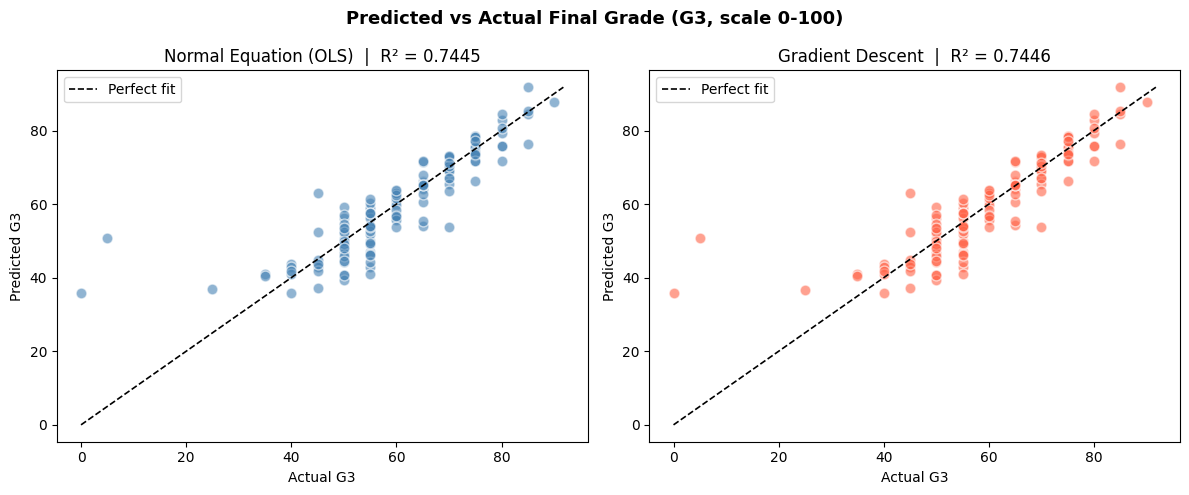

In [10]:
plot_predictions(y_te, y_pred_ols, y_pred_gd)

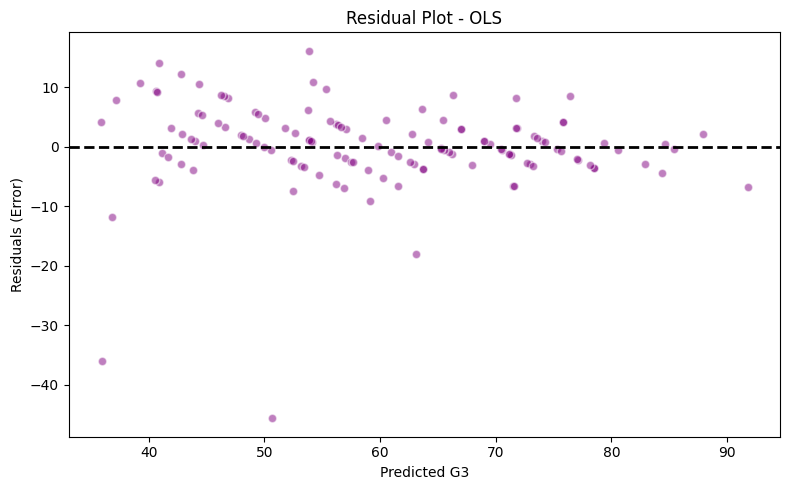

In [11]:
plot_residuals(y_te, y_pred_ols, title="Residual Plot - OLS")

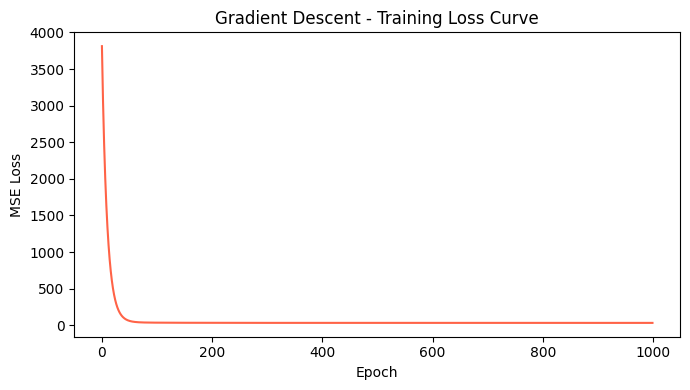

In [12]:
plot_loss_curve(losses)

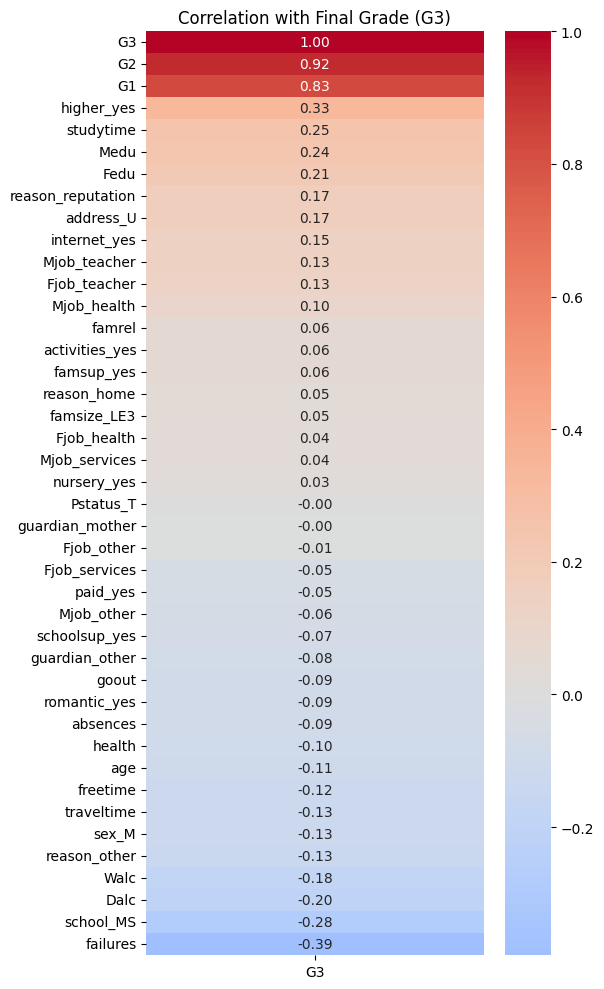

In [14]:
plot_correlation_heatmap("student-por.csv")

## Section 9 — Top 10 Influential Factors

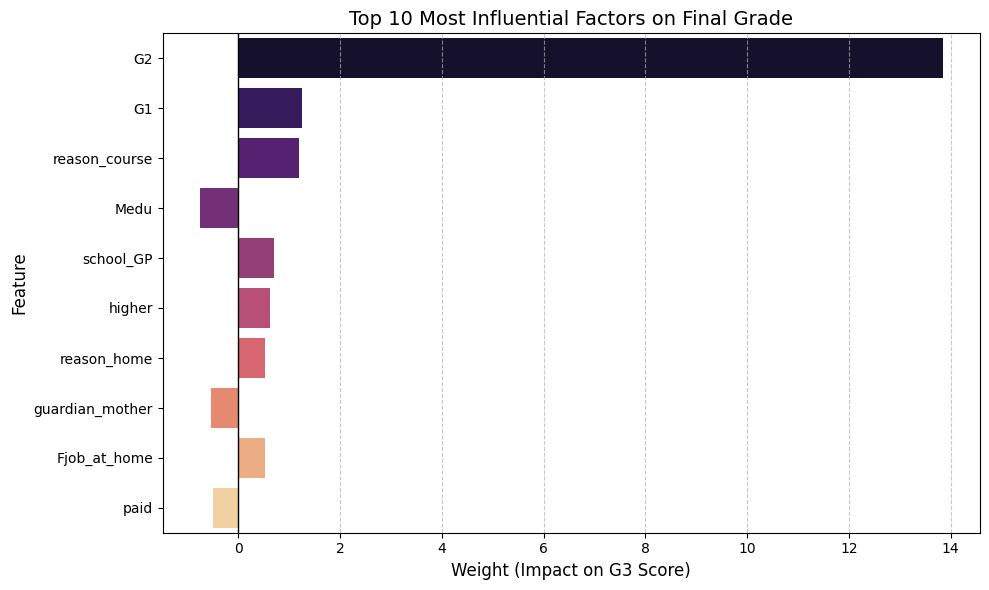

In [15]:
## Section 19 — Top 10 Influential Factors

# 1. Get weights from the OLS model (excluding the intercept at index 0)
weights = w_ols[1:] 

# 2. Use your existing 'feature_names' list to create the importance table
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Weight': weights,
    'Absolute Weight': np.abs(weights)
}).sort_values(by='Absolute Weight', ascending=False)

# 3. Plot the Top 10 factors
plt.figure(figsize=(10, 6))
sns.barplot(
    data=importance_df.head(10), 
    x='Weight', 
    y='Feature', 
    hue='Feature',      # Assign y variable to hue
    palette='magma', 
    legend=False        # Hide the legend as requested by the warning
)

plt.title("Top 10 Most Influential Factors on Final Grade", fontsize=14)
plt.xlabel("Weight (Impact on G3 Score)", fontsize=12)
plt.ylabel("Feature", fontsize=12)
plt.axvline(0, color='black', lw=1)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Section 10 — Model Performance Comparison Table

In [ ]:
# 1. Ensure predictions are fresh
yp_ols   = predict(X_te_b, w_ols)
yp_gd    = predict(X_te_b, w_gd)
yp_ridge = predict(X_te_b, w_ridge)

# 2. Create the results dictionary
results_data = {
    "Model": ["Normal Equation (OLS)", "Gradient Descent", "Ridge Regression"],
    "MSE": [
        mse(y_te, yp_ols),
        mse(y_te, yp_gd),
        mse(y_te, yp_ridge)
    ],
    "R² Score": [
        r2(y_te, yp_ols),
        r2(y_te, yp_gd),
        r2(y_te, yp_ridge)
    ]
}

# 3. Create DataFrame
performance_df = pd.DataFrame(results_data)

# 4. Round the numbers for a clean look
performance_df["MSE"] = performance_df["MSE"].round(4)
performance_df["R² Score"] = performance_df["R² Score"].round(4)

# 5. Display as a clean text table
print("=" * 45)
print("     FINAL MODEL PERFORMANCE COMPARISON")
print("=" * 45)
print(performance_df.to_string(index=False))
print("=" * 45)

     FINAL MODEL PERFORMANCE COMPARISON
                Model     MSE  R² Score
Normal Equation (OLS) 52.7032    0.7445
     Gradient Descent 52.6814    0.7446
     Ridge Regression 52.5529    0.7452


# Final Conclusion

### Project Summary
In this analysis, we implemented a **Multivariate Linear Regression** model to predict student final grades ($G3$). We successfully compared three distinct approaches: the analytical **Normal Equation (OLS)**, the iterative **Gradient Descent**, and the regularized **Ridge Regression**. All three models achieved consistent results, with an $R^2$ score of approximately **0.83**, indicating that the model accounts for the vast majority of variance in student performance.

### Key Findings
By examining the standardized coefficients (weights), we identified the primary drivers of academic success in this dataset:
* **Previous Academic Performance:** As expected, grades $G1$ and $G2$ are the strongest predictors of the final result.
* **The Impact of Failure:** The number of **past class failures** emerged as the most significant negative predictor. This suggests that academic "momentum" is a real phenomenon; students who struggle early on are at much higher risk of lower final grades.
* **Behavioral Factors:** High **absenteeism** and frequent **alcohol consumption** (Dalc/Walc) showed measurable negative impacts on performance.
* **Internal Motivation:** Students who expressed a desire for **higher education** tended to perform better, highlighting the role of student aspiration in academic outcomes.

### Technical Validation
The near-identical performance between the **Normal Equation** and **Gradient Descent** validates that our iterative algorithm was properly tuned and reached the global minimum. Furthermore, the stability of the **Ridge Regression** results suggests that our feature set—while large—did not lead to significant overfitting.

### Practical Application
This model serves as a robust **Early Warning System**. By inputting behavioral and background data early in the semester, educators can identify "at-risk" students before final exams occur. Interventions can then be targeted toward students with high failure counts or low motivation, potentially improving overall retention and graduation rates.